In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
from functions import dL_rosenbrock_1d
import pandas as pd
from src.optimizer import AdamScratch1D
from src.utils import AdamPlotter
import matplotlib.pyplot as plt
import numpy as np
from config import *

# DISCRETE-ADAM

In [3]:

optimizer = AdamScratch1D(
    dL = dL_rosenbrock_1d,
    lr=lr,
    beta1=beta1,
    beta2=beta2,
    epsilon=epsilon,
    epochs=epochs
)

theta_history, m_history, v_history, iterations = optimizer.solve(
    theta_initial=initial_theta,
    function_parameters=(c_value,)
    )

print(f"Final value of theta: {theta_history[-1]}")


Epoch: 50, theta=-9.896007e-01, Error: 1.027760e-02
Epoch: 100, theta=-4.760771e-01, Error: 1.005824e-02
Epoch: 150, theta=1.686920e-02, Error: 9.853259e-03
Epoch: 200, theta=5.132079e-01, Error: 1.000579e-02
Epoch: 250, theta=1.006840e+00, Error: 6.238333e-03
Last epoch: 270, Error: 3.632916e-03
Final value of theta: 0.9949003553847908


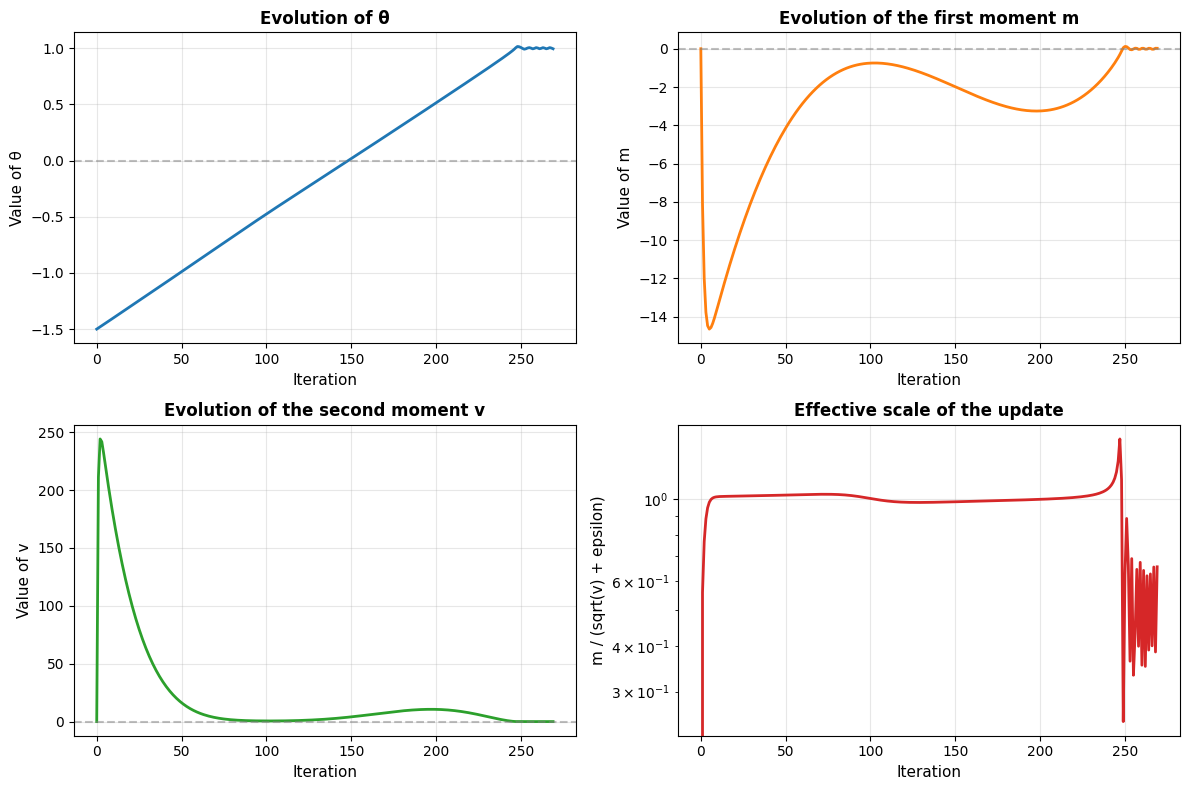

In [4]:
# Create Plotter and visualize
plotter = AdamPlotter(theta_history, m_history, v_history)

# Plot all
plotter.plot('all')
plt.show()

## Save Results

In [5]:
# Create DataFrame
df_discrete = pd.DataFrame({
    't': np.arange(len(theta_history)),
    'theta_history': theta_history,
    'theta_dot_history': None,
    'theta_ddot_history': None,
    'm_history': m_history,
    'v_history': v_history
})

# Save to CSV
df_discrete.to_csv(f'results/c_{c_value}_results_initial_theta_{initial_theta}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv', index=False)
print(f"Results saved in 'results/c_{c_value}_results_initial_theta_{initial_theta}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv'")
print(f"Total rows: {len(df_discrete)}")

Results saved in 'results/c_1.5_results_initial_theta_-1.5_lr_0.01_beta1_0.5_beta2_0.2.csv'
Total rows: 270
